# MusicPulse — Firestore et Redis appliqués aux données musicales

Notebook de démarche destiné au livrable. L'objectif principal est d'expliquer le stockage documentaire durable dans Firestore et les structures rapides de Redis. La recommandation musicale sert de cas d'usage.

Le notebook utilise l'échantillon versionné ; remplacer les chemins pour travailler sur les fichiers Kaggle complets.

In [4]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path('..')
tracks = pd.read_csv(ROOT / 'data/sample/tracks_sample.csv')
history = pd.read_csv(ROOT / 'data/sample/listening_history_sample.csv')
tracks.shape, history.shape

((2000, 21), (100000, 3))

## Exploration, qualité et préparation pour les bases NoSQL

- nombreux genres manquants ;
- tags multivalués séparés par des virgules ;
- historique beaucoup plus volumineux que le catalogue ;
- forte concentration des écoutes ;
- nécessité de traiter l'historique par chunks ;
- besoin de dénormaliser les documents Firestore ;
- besoin de choisir les agrégats et classements à précharger dans Redis.

In [5]:
missing = (tracks.isna().mean() * 100).sort_values(ascending=False)
missing.head(10)

genre                  36.2
tags                    0.9
artist                  0.0
name                    0.0
track_id                0.0
spotify_id              0.0
spotify_preview_url     0.0
year                    0.0
duration_ms             0.0
danceability            0.0
dtype: float64

In [6]:
tracks['primary_genre'] = tracks['genre']
fallback = tracks['tags'].fillna('Unknown').str.split(',').str[0].str.strip()
tracks['primary_genre'] = tracks['primary_genre'].fillna(fallback)
tracks[['genre', 'tags', 'primary_genre']].head()

,genre,tags,primary_genre
0,Rock,"rock, alternative, indie, alternative_rock, in...",Rock
1,NaN,"rock, alternative, indie, pop, alternative_roc...",rock
2,NaN,"rock, alternative, metal, alternative_rock, ha...",rock
3,Rock,"rock, alternative, indie, alternative_rock, in...",Rock
4,Rock,"rock, alternative, indie, pop, alternative_roc...",Rock


## Agrégations métier

In [7]:
plays = history.groupby('track_id', as_index=False)['playcount'].sum()
top = plays.nlargest(20, 'playcount').merge(tracks[['track_id', 'name', 'artist']], on='track_id')
top[['name', 'artist', 'playcount']]

,name,artist,playcount
0,Revelry,Kings of Leon,10514
1,Alejandro,Lady Gaga,2184
2,Gears,Miss May I,1873
3,Bring Me To Life,Katherine Jenkins,1803
4,Float On,Modest Mouse,1618
5,Uprising,Sabaton,1574
6,Halo,Depeche Mode,1555
7,It Was A Good Day,Ice Cube,1538
8,Party In The U.S.A.,The Barden Bellas,1531
9,Heartbreak Warfare,John Mayer,1506


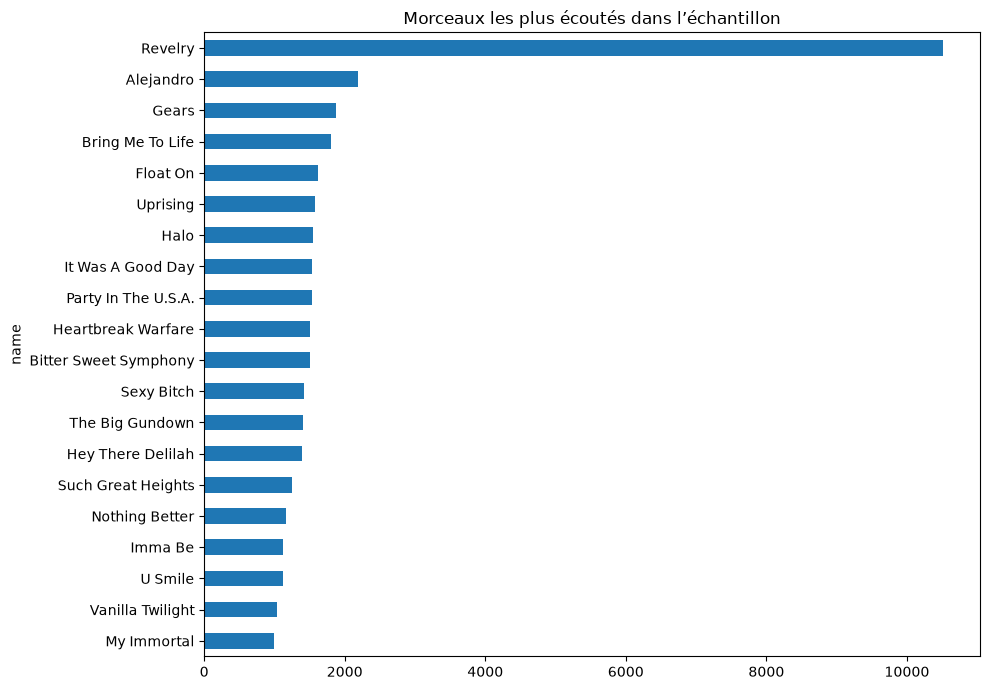

In [8]:
top.sort_values('playcount').plot.barh(x='name', y='playcount', figsize=(10, 7), legend=False)
plt.title('Morceaux les plus écoutés dans l’échantillon')
plt.tight_layout();